# Steam Game Market Analysis - Database Edition

This notebook performs comprehensive analysis of Steam game market data using Postgres database operations.

**Features:**
- Memory-efficient database queries for large-scale data (50M+ reviews)
- Interactive visualizations and market insights
- Genre-based filtering and analysis
- User behavior and game popularity metrics
- Market concentration analysis

**Prerequisites:**
- Run the database assembler first: `cd graph-analyser/assemble-graph-database && make run`
- Ensure `steam_reviews.db` exists in the working directory or specify the path below

## Import Required Libraries

Import necessary libraries for database operations, data analysis, and visualization.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json
import warnings
import os
import gc
from pathlib import Path
from typing import List, Dict, Tuple, Optional

# PostgreSQL imports
try:
    import psycopg2
    from sqlalchemy import create_engine, text
    print("✓ PostgreSQL drivers loaded successfully")
except ImportError as e:
    print("❌ PostgreSQL dependencies missing. Please install:")
    print("   pip install psycopg2-binary sqlalchemy")
    raise e
  
# Load environment variables from .env file
from dotenv import load_dotenv

env_file = Path("assemble-graph-database/.env")
if env_file.exists():
    load_dotenv(env_file)
    print(f"✓ Loaded environment variables from {env_file}")
else:
    print(f"⚠️  .env file not found at {env_file}")
    print("💡 Using default values")

# Configure display settings
warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8')
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
pd.set_option('display.max_colwidth', 50)

print("✓ Libraries imported successfully")
print(f"✓ Pandas version: {pd.__version__}")
print(f"✓ Numpy version: {np.__version__}")

output_dir = Path("analysis_plots")
output_dir.mkdir(exist_ok=True)

✓ PostgreSQL drivers loaded successfully
✓ Loaded environment variables from assemble-graph-database/.env
✓ Libraries imported successfully
✓ Pandas version: 2.3.2
✓ Numpy version: 2.3.2


## Database Connection Setup

Connect to the Steam reviews SQLite database and verify its structure.

In [2]:
# PostgreSQL Database connection configuration

# Database connection parameters
DB_HOST = os.getenv('DB_HOST', '127.0.0.1')
DB_PORT = os.getenv('DB_PORT', '5432')
DB_USER = os.getenv('DB_USER', 'postgres')
DB_PASSWORD = os.getenv('DB_PASSWORD', 'postgres')
DB_NAME = os.getenv('DB_NAME', 'steam_reviews')
DB_SSLMODE = os.getenv('DB_SSLMODE', 'disable')

# PostgreSQL connection string
connection_string = f"postgresql://{DB_USER}:{DB_PASSWORD}@{DB_HOST}:{DB_PORT}/{DB_NAME}?sslmode={DB_SSLMODE}"

print(f"🐘 Connecting to PostgreSQL database:")
print(f"   Host: {DB_HOST}:{DB_PORT}")
print(f"   Database: {DB_NAME}")
print(f"   User: {DB_USER}")

# Connect to database
try:
    # Create SQLAlchemy engine for pandas integration
    engine = create_engine(connection_string)
    
    # Test connection with direct psycopg2
    conn = psycopg2.connect(
        host=DB_HOST,
        port=DB_PORT,
        user=DB_USER,
        password=DB_PASSWORD,
        database=DB_NAME
    )
    
    print(f"✓ Connected to PostgreSQL database: {DB_HOST}:{DB_PORT}/{DB_NAME}")
    
    # Get database size information
    cursor = conn.cursor()
    cursor.execute("""
        SELECT pg_size_pretty(pg_database_size(%s)) as db_size;
    """, (DB_NAME,))
    db_size = cursor.fetchone()[0]
    print(f"✓ Database size: {db_size}")
    cursor.close()
    
    # For pandas compatibility, we'll use the engine for pd.read_sql_query
    # Note: conn is psycopg2 connection, engine is SQLAlchemy engine
    
except Exception as e:
    print(f"❌ Database connection failed: {e}")
    print(f"💡 Make sure PostgreSQL is running and the database exists.")
    print(f"💡 Run: cd graph-analyser/assemble-graph-database && docker compose --env-file assemble-graph-database/.env up -d")
    raise

🐘 Connecting to PostgreSQL database:
   Host: 127.0.0.1:25432
   Database: steam_reviews
   User: postgres


✓ Connected to PostgreSQL database: 127.0.0.1:25432/steam_reviews
✓ Database size: 27 GB


## Correlation between centrality indicators and game success (nº of reviews)

Compute
- Degree centrality: identify popular games and very active players
- Harmonic centrality (in place of closeness since the graph isn't connected): identify ecletic players and popular games
- Betweenness centrality: identify players and games that connects different clusters
- Eigenvector centrality: identify "influential" games
- Cross-Clique centrality: identify "influential" games and players belonging to different groups
- Freeman Centralization: measure how centralized the network is on the most central game

#### Correlation between degree centrality and game success

Clearly, if we consider success a bigger number of reviews, than a game degree is correlated to the games review count with a correlation coefficient of 1.

## One-Mode Projection: Game-to-Game Network

Create a projection of the bipartite graph where:
- **Nodes**: Only games (removing users)
- **Edges**: Connect two games if they share at least one player/reviewer
- **Edge Weight**: Number of players who reviewed both games (shared audience strength)

This projection reveals game similarity and market overlap based on player behavior.

### Compute Centrality Metrics for Projected Graph

Compute harmonic centrality and betweenness centrality for games in the projected graph using NetworkX.

**Harmonic Centrality**: Measures how close a game is to all other games (using reciprocal distances). Better than closeness centrality for disconnected graphs.

**Betweenness Centrality**: Measures how often a game appears on shortest paths between other games. Identifies "bridge" games that connect different clusters.

In [4]:
# Import NetworkX for graph analysis
import networkx as nx
print("✓ NetworkX imported successfully")
print(f"✓ NetworkX version: {nx.__version__}")

# Add columns for centrality metrics
print("\n🔧 Adding centrality metric columns to games table...")
print("=" * 60)

add_centrality_columns_query = """
ALTER TABLE games 
ADD COLUMN IF NOT EXISTS projection_harmonic_centrality FLOAT,
ADD COLUMN IF NOT EXISTS projection_betweenness_centrality FLOAT;
"""

with engine.begin() as connection:
    connection.execute(text(add_centrality_columns_query))

print("✓ projection_harmonic_centrality column added (if not existed)")
print("✓ projection_betweenness_centrality column added (if not existed)")

# Load projection graph into NetworkX
print("\n⏳ Loading projection graph into NetworkX...")
print("💡 This may take a moment for large graphs...")

# Create NetworkX graph
G = nx.Graph()

# First, add all game nodes (including isolated ones)
print("\n📋 Adding all game nodes to the graph...")
nodes_query = "SELECT game_id FROM games"
nodes_df = pd.read_sql_query(nodes_query, engine)
G.add_nodes_from(nodes_df['game_id'])
print(f"✓ Added {len(nodes_df):,} game nodes to the graph")

# Then, fetch and add all edges from the projection table in batches
print("\n🔗 Adding edges from projection table in batches...")

# Get total number of edges
count_query = "SELECT COUNT(*) as count FROM game_projection_edges"
total_edges = pd.read_sql_query(count_query, engine)['count'].iloc[0]
print(f"   Total edges to process: {total_edges:,}")

# Process edges in batches to avoid memory issues
batch_size = 10000000  # Process 10M edges at a time
offset = 0
edges_added = 0

while offset < total_edges:
    print(f"   Processing batch {offset:,} to {min(offset + batch_size, total_edges):,}...", end=" ")
    
    # Fetch batch of edges
    batch_query = f"""
    SELECT game_id_1, game_id_2, weight 
    FROM game_projection_edges 
    ORDER BY id
    LIMIT {batch_size} OFFSET {offset}
    """
    edges_batch = pd.read_sql_query(batch_query, engine)
    
    # Add edges from this batch
    for _, row in edges_batch.iterrows():
        G.add_edge(row['game_id_1'], row['game_id_2'], weight=row['weight'])
        edges_added += 1
    
    print(f"✓ ({edges_added:,} total)")
    
    # Free memory after each batch
    del edges_batch
    gc.collect()
    
    offset += batch_size

print(f"✓ Added all {edges_added:,} edges to the graph")

print(f"\n✓ Created NetworkX graph")
print(f"   Total nodes: {G.number_of_nodes():,}")
print(f"   Nodes with edges: {G.number_of_nodes() - nx.number_of_isolates(G):,}")
print(f"   Isolated nodes: {nx.number_of_isolates(G):,}")
print(f"   Edges: {G.number_of_edges():,}")
print(f"   Connected components: {nx.number_connected_components(G):,}")

✓ NetworkX imported successfully
✓ NetworkX version: 3.5

🔧 Adding centrality metric columns to games table...
✓ projection_harmonic_centrality column added (if not existed)
✓ projection_betweenness_centrality column added (if not existed)

⏳ Loading projection graph into NetworkX...
💡 This may take a moment for large graphs...

📋 Adding all game nodes to the graph...
✓ Added 98,101 game nodes to the graph

🔗 Adding edges from projection table in batches...
   Total edges to process: 49,997,708
   Processing batch 0 to 10,000,000... ✓ (10,000,000 total)
   Processing batch 10,000,000 to 20,000,000... ✓ (20,000,000 total)
   Processing batch 20,000,000 to 30,000,000... ✓ (30,000,000 total)
   Processing batch 30,000,000 to 40,000,000... ✓ (40,000,000 total)
   Processing batch 40,000,000 to 49,997,708... ✓ (49,997,708 total)
✓ Added all 49,997,708 edges to the graph

✓ Created NetworkX graph
   Total nodes: 98,101
   Nodes with edges: 32,244
   Isolated nodes: 65,857
   Edges: 49,997,70

In [5]:
# Get the largest connected component for analysis
if nx.number_connected_components(G) > 1:
    print("\n⚠️  Graph has multiple components")
    largest_cc = max(nx.connected_components(G), key=len)
    print(f"   Largest component size: {len(largest_cc):,} nodes")
    G_main = G.subgraph(largest_cc)
    print(f"💡 Using largest component for centrality computation")
else:
    G_main = G
    print("✓ Graph is connected")

print("\n✅ Graph loaded successfully!")
gc.collect()


⚠️  Graph has multiple components
   Largest component size: 32,220 nodes
💡 Using largest component for centrality computation

✅ Graph loaded successfully!


46

#### Compute Harmonic Centrality

Harmonic centrality is computed as the sum of reciprocal distances to all other nodes. It works well for disconnected graphs.

In [10]:
gc.collect()

import random

# Sample
sample_size = 100
print(f"💡 Sampling {sample_size:,} nodes for harmonic centrality computation...")
sampled_nodes = random.sample(list(G.nodes()), sample_size)

# Compute Harmonic Centrality
print("📊 Computing Harmonic Centrality for all games...")
print("=" * 60)
print("⏳ This may take several minutes for large graphs...")

harmonic_centrality = nx.harmonic_centrality(G, sources=sampled_nodes)

print(f"✓ Computed harmonic centrality for {len(harmonic_centrality):,} games")

# Convert to DataFrame for database insertion
harmonic_df = pd.DataFrame([
    {'game_id': game_id, 'harmonic_centrality': centrality}
    for game_id, centrality in harmonic_centrality.items()
])

# Get statistics
print("\n📊 Harmonic Centrality Statistics:")
print("-" * 60)
print(f"   Min: {harmonic_df['harmonic_centrality'].min():.6f}")
print(f"   Max: {harmonic_df['harmonic_centrality'].max():.6f}")
print(f"   Mean: {harmonic_df['harmonic_centrality'].mean():.6f}")
print(f"   Median: {harmonic_df['harmonic_centrality'].median():.6f}")
print(f"   Std Dev: {harmonic_df['harmonic_centrality'].std():.6f}")

💡 Sampling 100 nodes for harmonic centrality computation...
📊 Computing Harmonic Centrality for all games...
⏳ This may take several minutes for large graphs...
✓ Computed harmonic centrality for 98,101 games

📊 Harmonic Centrality Statistics:
------------------------------------------------------------
   Min: 0.000000
   Max: 27.000000
   Mean: 5.427850
   Median: 0.000000
   Std Dev: 7.878250


In [19]:
# Update database with harmonic centrality values
print("\n💾 Storing harmonic centrality values in database...")

# Create a temporary table for efficient bulk update
with engine.begin() as connection:
    connection.execute(text("""
        UPDATE games g
        SET projection_harmonic_centrality = NULL
    """))

    # Create temporary table
    connection.execute(text("""
        CREATE TEMP TABLE temp_harmonic_centrality (
            game_id VARCHAR(255) PRIMARY KEY,
            harmonic_centrality FLOAT
        )
    """))

    # Insert data into temporary table
    harmonic_df.to_sql('temp_harmonic_centrality', connection,
                       if_exists='append', index=False)

    # Update main table from temporary table
    connection.execute(text("""
        UPDATE games g
        SET projection_harmonic_centrality = t.harmonic_centrality
        FROM temp_harmonic_centrality t
        WHERE g.game_id = t.game_id
    """))

    # Drop temporary table
    connection.execute(text("DROP TABLE temp_harmonic_centrality"))

print(f"✓ Updated {len(harmonic_df):,} games with harmonic centrality values")

# Show top games by harmonic centrality
print("\n🏆 Top 10 Games by Harmonic Centrality:")
print("-" * 60)

top_harmonic_query = """
SELECT 
    game_id,
    name,
    projection_harmonic_centrality,
    projection_degree,
    projection_weighted_degree
FROM games
WHERE projection_harmonic_centrality > 0
ORDER BY projection_harmonic_centrality DESC
LIMIT 10;
"""

top_harmonic_df = pd.read_sql_query(top_harmonic_query, engine)
print(top_harmonic_df.to_string(index=False))

print("\n✅ Harmonic centrality computation complete!")


💾 Storing harmonic centrality values in database...
✓ Updated 98,101 games with harmonic centrality values

🏆 Top 10 Games by Harmonic Centrality:
------------------------------------------------------------
game_id                  name  projection_harmonic_centrality  projection_degree  projection_weighted_degree
 242760            The Forest                            27.0              20250                     2633137
1086940       Baldur's Gate 3                            27.0              21531                     3207897
 251570         7 Days to Die                            26.5              16180                      726691
 264710            Subnautica                            26.5              19054                     1668987
 108710             Alan Wake                            26.5              18729                     1060497
 214490      Alien: Isolation                            26.0              16895                      896449
1237970          Titanfall® 

#### Correlation between Harmonic Centrality and Bipartite Degree

Analyze the correlation between harmonic centrality in the projected graph and the degree in the original bipartite graph.

In [48]:
# Compute correlation between Harmonic Centrality and Bipartite Degree
print("📊 Computing Correlation: Harmonic Centrality vs Bipartite Degree")
print("=" * 60)

# Query to get games with harmonic centrality computed
correlation_query = """
SELECT 
    game_id,
    name,
    degree as bipartite_degree,
    projection_harmonic_centrality
FROM games
WHERE projection_harmonic_centrality IS NOT NULL
ORDER BY projection_harmonic_centrality DESC;
"""

correlation_df = pd.read_sql_query(correlation_query, engine)

print(f"✓ Loaded {len(correlation_df):,} games with harmonic centrality computed")

# Compute Pearson correlation coefficient
from scipy.stats import pearsonr, spearmanr

pearson_corr, pearson_pvalue = pearsonr(
    correlation_df['bipartite_degree'], 
    correlation_df['projection_harmonic_centrality']
)

spearman_corr, spearman_pvalue = spearmanr(
    correlation_df['bipartite_degree'], 
    correlation_df['projection_harmonic_centrality']
)

print(f"\n📈 Correlation Statistics:")
print("-" * 60)
print(f"   Pearson Correlation:  {pearson_corr:.6f} (p-value: {pearson_pvalue:.2e})")
print(f"   Spearman Correlation: {spearman_corr:.6f} (p-value: {spearman_pvalue:.2e})")

if pearson_pvalue < 0.001:
    print("   ✓ Correlation is statistically significant (p < 0.001)")
elif pearson_pvalue < 0.05:
    print("   ✓ Correlation is statistically significant (p < 0.05)")
else:
    print("   ⚠️  Correlation is not statistically significant")

# Interpretation
print("\n💡 Interpretation:")
if abs(pearson_corr) > 0.7:
    strength = "strong"
elif abs(pearson_corr) > 0.4:
    strength = "moderate"
elif abs(pearson_corr) > 0.2:
    strength = "weak"
else:
    strength = "very weak"

direction = "positive" if pearson_corr > 0 else "negative"
print(f"   There is a {strength} {direction} correlation between bipartite degree")
print(f"   and harmonic centrality in the projected graph.")


📊 Computing Correlation: Harmonic Centrality vs Bipartite Degree
✓ Loaded 98,101 games with harmonic centrality computed

📈 Correlation Statistics:
------------------------------------------------------------
   Pearson Correlation:  0.130872 (p-value: 0.00e+00)
   Spearman Correlation: 0.982682 (p-value: 0.00e+00)
   ✓ Correlation is statistically significant (p < 0.001)

💡 Interpretation:
   There is a very weak positive correlation between bipartite degree
   and harmonic centrality in the projected graph.



📊 Creating correlation visualization...


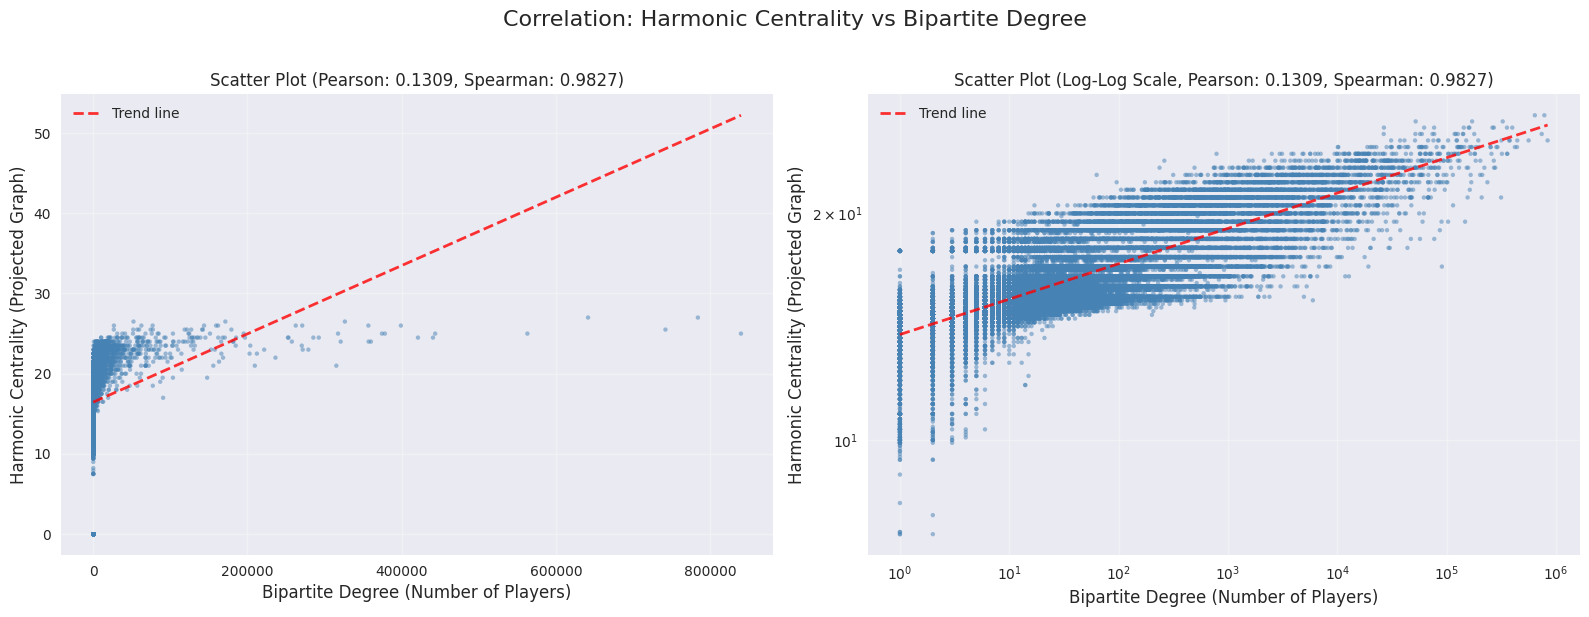

In [50]:
print("\n📊 Creating correlation visualization...")

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Correlation: Harmonic Centrality vs Bipartite Degree',
             fontsize=16, y=1.02)

# Scatter plot
ax1 = axes[0]

def plot_graph(ax, log_scale: bool = False, line_of_best_fit: bool = True):
  ax.scatter(
      correlation_df['bipartite_degree'],
      correlation_df['projection_harmonic_centrality'],
      alpha=0.5,
      s=10,
      c='steelblue',
      edgecolors='none'
  )
  ax.set_xlabel('Bipartite Degree (Number of Players)', fontsize=12)
  ax.set_ylabel('Harmonic Centrality (Projected Graph)', fontsize=12)
  ax.set_title(
      f'Scatter Plot ({'Log-Log Scale, ' if log_scale else ''}Pearson: {pearson_corr:.4f}, Spearman: {spearman_corr:.4f})', fontsize=12)
  ax.grid(True, alpha=0.3)
  if log_scale:
      ax.set_xscale('log')
      ax.set_yscale('log')
  
  # Add line of best fit if requested
  if line_of_best_fit:
    try:
      valid_mask = (correlation_df['bipartite_degree'] > 0) & \
                   (correlation_df['projection_harmonic_centrality'] > 0) & \
                   np.isfinite(correlation_df['bipartite_degree']) & \
                   np.isfinite(correlation_df['projection_harmonic_centrality'])
      
      if valid_mask.sum() > 10:
        valid_x = correlation_df.loc[valid_mask, 'bipartite_degree']
        valid_y = correlation_df.loc[valid_mask, 'projection_harmonic_centrality']
        
        if log_scale:
          z = np.polyfit(np.log10(valid_x), np.log10(valid_y), 1)
          p = np.poly1d(z)
          x_trend = np.logspace(np.log10(valid_x.min()), np.log10(valid_x.max()), 100)
          y_trend = 10 ** p(np.log10(x_trend))
        else:
          z = np.polyfit(valid_x, valid_y, 1)
          p = np.poly1d(z)
          x_trend = np.linspace(valid_x.min(), valid_x.max(), 100)
          y_trend = p(x_trend)
        
        ax.plot(x_trend, y_trend, "r--", alpha=0.8, linewidth=2, label='Trend line')
        ax.legend()
    except Exception as e:
      pass
  plt.tight_layout()

plot_graph(axes[0])
plot_graph(axes[1], log_scale=True)

plt.savefig(output_dir / 'harmonic_vs_bipartite_degree.png',
            dpi=300, bbox_inches='tight')
plt.show()

In [51]:
# Show top games by both metrics
print("\n🏆 Top 10 Games by Bipartite Degree:")
print("-" * 60)
top_by_degree = correlation_df.nlargest(10, 'bipartite_degree')[
    ['game_id', 'name', 'bipartite_degree', 'projection_harmonic_centrality']
]
print(top_by_degree.to_string(index=False))

print("\n🏆 Top 10 Games by Harmonic Centrality:")
print("-" * 60)
top_by_harmonic = correlation_df.nlargest(10, 'projection_harmonic_centrality')[
    ['game_id', 'name', 'bipartite_degree', 'projection_harmonic_centrality']
]
print(top_by_harmonic.to_string(index=False))


🏆 Top 10 Games by Bipartite Degree:
------------------------------------------------------------
game_id                   name  bipartite_degree  projection_harmonic_centrality
 292030 Ведьмак 3: Дикая Охота            840001                            25.0
1086940        Baldur's Gate 3            784098                            27.0
1245620             ELDEN RING            742058                            25.5
 242760             The Forest            641676                            27.0
1091500         Cyberpunk 2077            562983                            25.0
1097150              Fall Guys            443394                            25.0
 221100                   DayZ            440567                            24.5
 374320        DARK SOULS™ III            421076                            24.5
 377160              Fallout 4            398929                            26.0
 218620               PAYDAY 2            378183                            25.0

🏆 Top 10 G

#### Compute Betweenness Centrality

Betweenness centrality measures how often a node appears on shortest paths between other nodes. For disconnected graphs, we compute it on the largest connected component and set to 0 for isolated nodes.

In [ ]:
gc.collect()

sample = 5
# Compute Betweenness Centrality
print("📊 Computing Betweenness Centrality for all games...")
print("=" * 60)
print("⏳ This computation can be slow for large graphs (O(n³) complexity)...")
print("💡 Computing on largest connected component, others will have 0 centrality")

# Initialize betweenness centrality dictionary with 0 for all nodes
betweenness_centrality = {node: 0.0 for node in G.nodes()}

# Compute betweenness centrality only on the largest connected component
if nx.number_connected_components(G) > 1:
    # Get all connected components
    components = list(nx.connected_components(G))
    components.sort(key=len, reverse=True)
    
    print(f"\n   Processing {len(components)} connected components:")
    
    # Process each component (or just the largest ones to save time)
    max_components = min(10, len(components))  # Process up to 10 largest components
    
    for i, component in enumerate(components[:max_components]):
        if len(component) > 1:  # Only compute for components with more than 1 node
            print(f"   Component {i+1}: {len(component):,} nodes", end="... ")
            G_component = G.subgraph(component)
            
            component_betweenness = nx.betweenness_centrality(
                G_component, k=min(sample, len(component)), normalized=True)
            betweenness_centrality.update(component_betweenness)
            print("✓")
        else:
            print(f"   Component {i+1}: {len(component):,} nodes (isolated, skipped)")
    
    if len(components) > max_components:
        print(f"   ... and {len(components) - max_components} smaller components (set to 0)")
else:
    print("   Graph is connected, computing for all nodes...")
    betweenness_centrality = nx.betweenness_centrality(
        G, k=sample, normalized=True)

print(f"\n✓ Computed betweenness centrality for {len(betweenness_centrality):,} games")

📊 Computing Betweenness Centrality for all games...
⏳ This computation can be slow for large graphs (O(n³) complexity)...
💡 Computing on largest connected component, others will have 0 centrality

   Processing 65866 connected components:
   Component 1: 32,220 nodes... ✓
   Component 2: 5 nodes... ✓
   Component 3: 4 nodes... 

ValueError: Sample larger than population or is negative

In [35]:
# Convert to DataFrame for database insertion
betweenness_df = pd.DataFrame([
    {'game_id': game_id, 'betweenness_centrality': centrality}
    for game_id, centrality in betweenness_centrality.items()
])

# Get statistics
print("\n📊 Betweenness Centrality Statistics:")
print("-" * 60)
print(f"   Min: {betweenness_df['betweenness_centrality'].min():.6f}")
print(f"   Max: {betweenness_df['betweenness_centrality'].max():.6f}")
print(f"   Mean: {betweenness_df['betweenness_centrality'].mean():.6f}")
print(f"   Median: {betweenness_df['betweenness_centrality'].median():.6f}")
print(f"   Std Dev: {betweenness_df['betweenness_centrality'].std():.6f}")
print(
    f"   Non-zero values: {(betweenness_df['betweenness_centrality'] > 0).sum():,}")


📊 Betweenness Centrality Statistics:
------------------------------------------------------------
   Min: 0.000000
   Max: 0.200025
   Mean: 0.000011
   Median: 0.000000
   Std Dev: 0.000656
   Non-zero values: 22,606


In [36]:

# Update database with betweenness centrality values
print("\n💾 Storing betweenness centrality values in database...")

# Create a temporary table for efficient bulk update
with engine.begin() as connection:
    # Create temporary table
    connection.execute(text("""
        CREATE TEMP TABLE temp_betweenness_centrality (
            game_id VARCHAR(255) PRIMARY KEY,
            betweenness_centrality FLOAT
        )
    """))

    # Insert data into temporary table
    betweenness_df.to_sql('temp_betweenness_centrality',
                          connection, if_exists='append', index=False)

    # Update main table from temporary table
    connection.execute(text("""
        UPDATE games g
        SET projection_betweenness_centrality = t.betweenness_centrality
        FROM temp_betweenness_centrality t
        WHERE g.game_id = t.game_id
    """))

    # Drop temporary table
    connection.execute(text("DROP TABLE temp_betweenness_centrality"))

print(
    f"✓ Updated {len(betweenness_df):,} games with betweenness centrality values")


💾 Storing betweenness centrality values in database...
✓ Updated 98,101 games with betweenness centrality values


In [37]:

# Show top games by betweenness centrality
print("\n🏆 Top 10 Games by Betweenness Centrality:")
print("-" * 60)

top_betweenness_query = """
SELECT 
    game_id,
    name,
    projection_betweenness_centrality,
    projection_degree,
    projection_weighted_degree,
    projection_harmonic_centrality
FROM games
WHERE projection_betweenness_centrality > 0
ORDER BY projection_betweenness_centrality DESC
LIMIT 10;
"""

top_betweenness_df = pd.read_sql_query(top_betweenness_query, engine)
print(top_betweenness_df.to_string(index=False))

print("\n✅ Betweenness centrality computation complete!")


🏆 Top 10 Games by Betweenness Centrality:
------------------------------------------------------------
game_id                                      name  projection_betweenness_centrality  projection_degree  projection_weighted_degree  projection_harmonic_centrality
3217130                                Plot Twist                           0.200025                637                         660                       15.666667
1086940                           Baldur's Gate 3                           0.025851              21531                     3207897                       27.000000
 107410                                    Arma 3                           0.012522              16422                     1295785                       24.500000
1063730                       New World: Aeternum                           0.011741              16030                      835050                       26.000000
 405640                               Pony Island                           

In [52]:
# Compute correlation between Betweenness Centrality and Bipartite Degree
from scipy.stats import pearsonr, spearmanr
print("📊 Computing Correlation: Betweenness Centrality vs Bipartite Degree")
print("=" * 60)

# Query to get games with betweenness centrality computed
correlation_query = """
SELECT 
    game_id,
    name,
    degree as bipartite_degree,
    projection_betweenness_centrality
FROM games
WHERE projection_betweenness_centrality IS NOT NULL
ORDER BY projection_betweenness_centrality DESC;
"""

correlation_df = pd.read_sql_query(correlation_query, engine)

print(
    f"✓ Loaded {len(correlation_df):,} games with betweenness centrality computed")

# Compute Pearson correlation coefficient

pearson_corr, pearson_pvalue = pearsonr(
    correlation_df['bipartite_degree'],
    correlation_df['projection_betweenness_centrality']
)

spearman_corr, spearman_pvalue = spearmanr(
    correlation_df['bipartite_degree'],
    correlation_df['projection_betweenness_centrality']
)

print(f"\n📈 Correlation Statistics:")
print("-" * 60)
print(
    f"   Pearson Correlation:  {pearson_corr:.6f} (p-value: {pearson_pvalue:.2e})")
print(
    f"   Spearman Correlation: {spearman_corr:.6f} (p-value: {spearman_pvalue:.2e})")

if pearson_pvalue < 0.001:
    print("   ✓ Correlation is statistically significant (p < 0.001)")
elif pearson_pvalue < 0.05:
    print("   ✓ Correlation is statistically significant (p < 0.05)")
else:
    print("   ⚠️  Correlation is not statistically significant")

# Interpretation
print("\n💡 Interpretation:")
if abs(pearson_corr) > 0.7:
    strength = "strong"
elif abs(pearson_corr) > 0.4:
    strength = "moderate"
elif abs(pearson_corr) > 0.2:
    strength = "weak"
else:
    strength = "very weak"

direction = "positive" if pearson_corr > 0 else "negative"
print(
    f"   There is a {strength} {direction} correlation between bipartite degree")
print(f"   and betweenness centrality in the projected graph.")

📊 Computing Correlation: Betweenness Centrality vs Bipartite Degree


✓ Loaded 98,101 games with betweenness centrality computed

📈 Correlation Statistics:
------------------------------------------------------------
   Pearson Correlation:  0.111515 (p-value: 6.25e-269)
   Spearman Correlation: 0.850093 (p-value: 0.00e+00)
   ✓ Correlation is statistically significant (p < 0.001)

💡 Interpretation:
   There is a very weak positive correlation between bipartite degree
   and betweenness centrality in the projected graph.



📊 Creating correlation visualization...


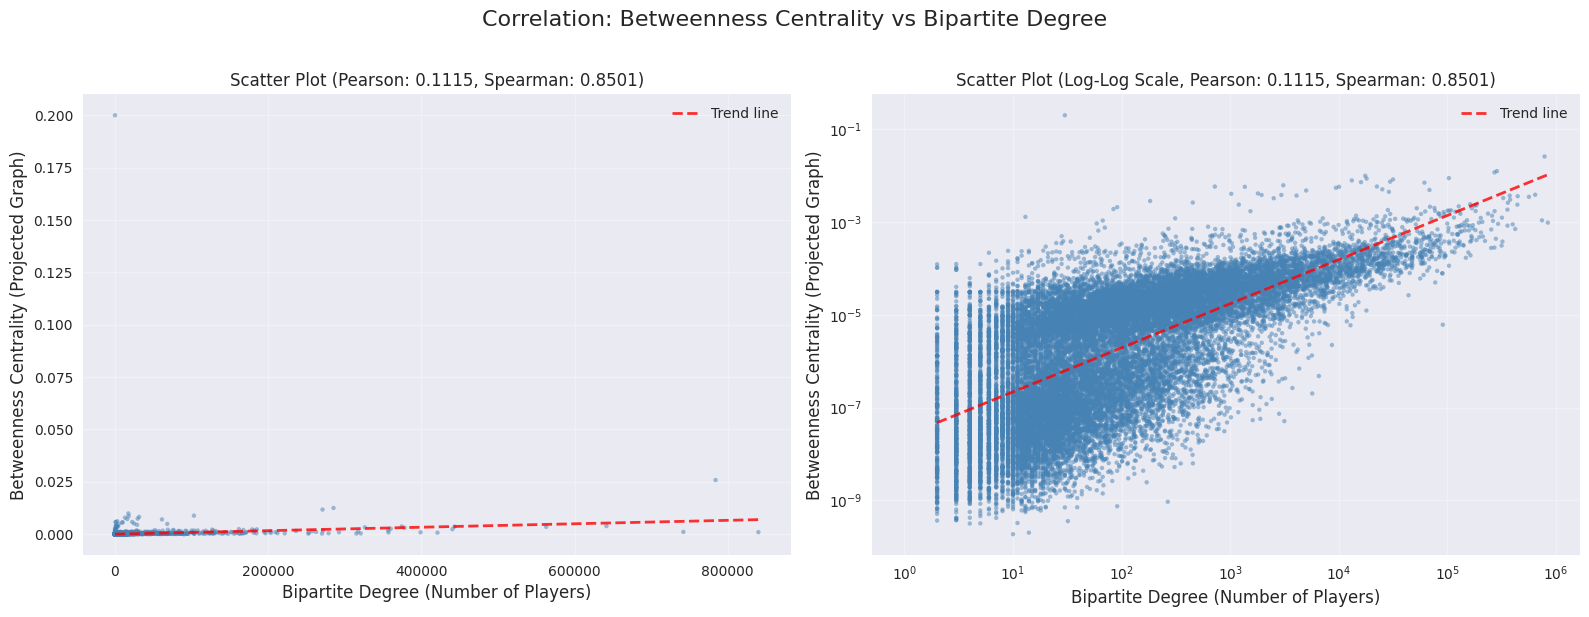

In [53]:
print("\n📊 Creating correlation visualization...")

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Correlation: Betweenness Centrality vs Bipartite Degree',
             fontsize=16, y=1.02)

# Scatter plot
ax1 = axes[0]


def plot_graph(ax, log_scale: bool = False, line_of_best_fit: bool = True):
  ax.scatter(
      correlation_df['bipartite_degree'],
      correlation_df['projection_betweenness_centrality'],
      alpha=0.5,
      s=10,
      c='steelblue',
      edgecolors='none'
  )
  ax.set_xlabel('Bipartite Degree (Number of Players)', fontsize=12)
  ax.set_ylabel('Betweenness Centrality (Projected Graph)', fontsize=12)
  ax.set_title(
      f'Scatter Plot ({'Log-Log Scale, ' if log_scale else ''}Pearson: {pearson_corr:.4f}, Spearman: {spearman_corr:.4f})', fontsize=12)
  ax.grid(True, alpha=0.3)
  if log_scale:
      ax.set_xscale('log')
      ax.set_yscale('log')

  # Add line of best fit if requested
  if line_of_best_fit:
    try:
      valid_mask = (correlation_df['bipartite_degree'] > 0) & \
                   (correlation_df['projection_betweenness_centrality'] > 0) & \
          np.isfinite(correlation_df['bipartite_degree']) & \
          np.isfinite(correlation_df['projection_betweenness_centrality'])

      if valid_mask.sum() > 10:
        valid_x = correlation_df.loc[valid_mask, 'bipartite_degree']
        valid_y = correlation_df.loc[valid_mask,
                                     'projection_betweenness_centrality']

        if log_scale:
          z = np.polyfit(np.log10(valid_x), np.log10(valid_y), 1)
          p = np.poly1d(z)
          x_trend = np.logspace(np.log10(valid_x.min()),
                                np.log10(valid_x.max()), 100)
          y_trend = 10 ** p(np.log10(x_trend))
        else:
          z = np.polyfit(valid_x, valid_y, 1)
          p = np.poly1d(z)
          x_trend = np.linspace(valid_x.min(), valid_x.max(), 100)
          y_trend = p(x_trend)

        ax.plot(x_trend, y_trend, "r--", alpha=0.8,
                linewidth=2, label='Trend line')
        ax.legend()
    except Exception as e:
      pass

    plt.tight_layout()


plot_graph(axes[0])
plot_graph(axes[1], log_scale=True)

plt.savefig(output_dir / 'betweenness_vs_bipartite_degree.png', dpi=300, bbox_inches='tight')
plt.show()